In [2]:
import pandas as pd
import numpy as np
from modAL.models import ActiveLearner
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input, Activation, AveragePooling2D, Conv2DTranspose, ZeroPadding2D
from tensorflow.keras.layers import Dense , Dropout, Conv2D ,Flatten, Conv1D, BatchNormalization
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

from matplotlib import pyplot as plt
import seaborn as sns
import copy
import math

font_size = 18

(array([-800., -600., -400., -200.,    0.,  200.,  400.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

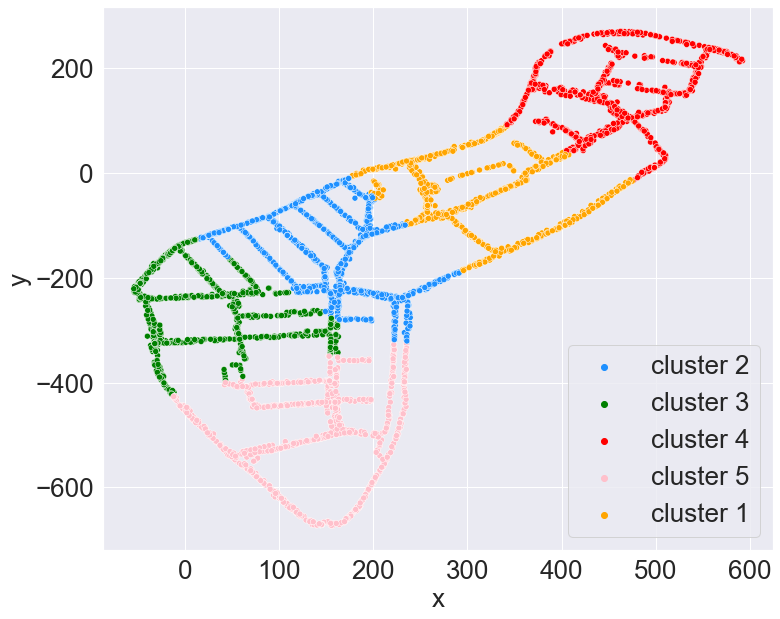

In [9]:
# load numpy raw data
with open('all_ae.npy', 'rb') as f:
    h2_ae = np.load(f)
    Pos = np.load(f)

h2_ae_shape = h2_ae.shape
h2_ae_1dcnn = h2_ae.reshape(h2_ae_shape[0], h2_ae_shape[1], -1)
h2_ae.shape, Pos.shape

# cluster the dataset for classification
pos_cluster = pd.DataFrame(Pos, columns=["x", "y", "z"])
kmeans = KMeans(n_clusters=5, random_state=42).fit(pos_cluster)
pos_cluster["cluster"] = kmeans.labels_
pos_cluster["cluster"] = pos_cluster["cluster"].replace({0: "cluster 1", 1: "cluster 2", 2: "cluster 3", 3: "cluster 4", 4: "cluster 5"})
pos_cluster["is_c1"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 1", 'is_c1'] = 1
pos_cluster["is_c2"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 2", 'is_c2'] = 1
pos_cluster["is_c3"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 3", 'is_c3'] = 1
pos_cluster["is_c4"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 4", 'is_c4'] = 1
pos_cluster["is_c5"] = 0
pos_cluster.loc[pos_cluster.cluster == "cluster 5", 'is_c5'] = 1

sns.set()
plt.figure(figsize=(12, 10))
ax = sns.scatterplot(x="x", y="y", data=pos_cluster, hue="cluster", palette=["dodgerblue", "green", "red", "pink", "orange"])
plt.ylabel("y", fontsize=font_size)
plt.xlabel("x", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

In [10]:
print("train-test splitting ae data...")
x_train_ae, x_test_ae, y_train_ae, y_test_ae = train_test_split(h2_ae, pos_cluster, test_size=0.1, random_state=42)
x_train_ae_cnn, x_test_ae_cnn, y_train, y_test = train_test_split(h2_ae_1dcnn, pos_cluster, test_size=0.1, random_state=42)

y_train_ae_cnn = y_train[["x", "y", "z"]].values
y_test_ae_cnn = y_test[["x", "y", "z"]].values
print("splitting training data and active learning pool...")
train_x_al, pool_x_al, train_y_al, pool_y_al = train_test_split(x_train_ae_cnn, y_train_ae_cnn, test_size=0.8, random_state=42)

y_train_cluster = y_train[["is_c1", "is_c2", "is_c3"]].values
y_test_cluster = y_test[["is_c1", "is_c2", "is_c3"]].values
train_x_cluster, pool_x_cluster, train_y_cluster, pool_y_cluster = train_test_split(x_train_ae_cnn, y_train_cluster, test_size=0.8, random_state=42)

train-test splitting ae data...
splitting training data and active learning pool...


In [37]:
def get_prediction_precision(regressor, x_test, y_test):
    y_pred = regressor.predict(x_test)
    mse = mean_squared_error(y_true=y_test, y_pred=y_pred)
    #print(f"current MSE: {mse}")
    return mse

def cnn_model1(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3))
    model.compile(loss='mean_squared_error', optimizer=opt)
    return model

# model for outputting probability
def cnn_model_clf(input_shape, opt=Adam(1e-3), dropout_rate=0.2):
    model = Sequential()
    model.add(Conv1D(16, 16, input_shape=input_shape, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Conv1D(32, 16, activation='relu'))
    model.add(Flatten())
    model.add(BatchNormalization())
    model.add(Dense(512))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(256))
    model.add(BatchNormalization())
    model.add(Activation('relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(3, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

print("constructing 1D-CNN models...")
lr = 5e-3
epochs = 50
decay_rate = lr / 50
model_ae = cnn_model1(train_x_al.shape[1:], opt=Adam(5e-3, decay=decay_rate))
model_clf = cnn_model_clf(train_x_cluster.shape[1:], opt=Adam(5e-3, decay=decay_rate))

constructing 1D-CNN models...


In [38]:
# 1. Fit on original training data
print(f"train_x_al:{train_x_al.shape}, train_y_al:{train_y_al.shape}")
model_ae.fit(train_x_al, train_y_al, epochs=1, validation_data=(
    x_test_ae_cnn, y_test_ae_cnn), verbose=1)
model_clf.fit(train_x_cluster, train_y_cluster, epochs=1, validation_data=(
    x_test_ae_cnn, y_test_cluster), verbose=1)
print(f"Initial round of training finished, MSE:{get_prediction_precision(model_ae, x_test_ae_cnn, y_test_ae_cnn)}")


train_x_al:(896, 56, 1184), train_y_al:(896, 3)
28/28 [==============================] - 2s 65ms/step - loss: 1.0959 - accuracy: 0.5257 - val_loss: 3.7513 - val_accuracy: 0.4659
Initial round of training finished, MSE:3766989.481863443


In [58]:
dist_dict = np.load('dist_dict.npy')

In [60]:
dist_dict.shape

(3585, 3585)

In [56]:
# dist_dict = []
# for i in range(len(pool_x_al)):
#     _row = []
#     for j in range(len(pool_x_al)):
#         _row.append(distance(pool_x_al[i], pool_x_al[j]))
#     dist_dict.append(_row)
# dist_dict = np.array(dist_dict)
# with open('dist_dict.npy', 'wb') as f:
#     np.save(f, dist_dict)
# print("dist_dict saved!")

In [64]:
def random_sampling(classifier, X_pool):
    n_samples = len(X_pool)
    query_idx = np.random.choice(range(n_samples))
    return [query_idx], X_pool[query_idx]

def distance(p1, p2):
    return np.linalg.norm(p1 - p2)

xs, ys = [], []
xs_idx = []
dist_dict = np.load('dist_dict.npy')
def location_based_sampling(classifier, X_pool):
    if len(X_pool) == 0:
        return random_sampling(classifier, X_pool)
    
    distances = [sum([dist_dict[chosen_idx][cur_idx] for chosen_idx in xs_idx]) for cur_idx, x in enumerate(X_pool)]
    query_idx = distances.index(max(distances))
    return [query_idx], X_pool[query_idx]

def location_based_sampling2(classifier, X_pool):
    overall_distances = [sum([dist_dict[_chosen_idx][cur_idx] for _chosen_idx in xs_idx]) + dist_dict_pretrain[cur_idx] for cur_idx, x in enumerate(X_pool)]
    overall_distances_np = np.array(overall_distances)
    maxes = classifier.predict_proba(X_pool).max(axis=1)
    uncertainties = np.full(len(overall_distances), 1) - maxes
    product = overall_distances_np * uncertainties
    query_idx = list(product).index(max(product))
    return query_idx, X_pool[query_idx]

In [43]:
dist_dict_pretrain = list(np.load('dist_dict_pretrain.npy'))
dist_dict_pretrain.index(max(dist_dict_pretrain))

2036

In [109]:
# print("Begin active learning process...")
# n_queries = 1700
# mode = "lb2"
# #queries_num = np.linspace(100, 3500, 35)
# mse_dict = {}
# all_chosen_samples = []
# mode_dict = {
#     "random": random_sampling,
#     "lb": location_based_sampling,
#     "lb2": location_based_sampling2
# }
# print("Initialize active learners...")
# regressor = ActiveLearner(
#     estimator=model_ae,
#     query_strategy=mode_dict[mode],
#     X_training=train_x_al, y_training=train_y_al
# )
# classifier = ActiveLearner(
#     estimator=model_clf,
#     query_strategy=mode_dict[mode],
#     X_training=train_x_al, y_training=train_y_cluster
# )
# print(f"active learning for {n_queries} epochs")


# i = 0
# pool_x_shape = pool_x_al.shape
# while i <= n_queries:
#     # get_prediction_precision(regressor, x_test_ae_cnn, y_test_ae_cnn)
#     if mode not in ["lb", "random"]:
#         query_idx, query_instance = classifier.query(pool_x_al)
#     else:
#         query_idx, query_instance = regressor.query(pool_x_al)
#     _x, _y_reg, _y_clf = pool_x_al[query_idx], pool_y_al[query_idx], pool_y_cluster[query_idx]
#     pool_x_al = np.delete(pool_x_al, query_idx, axis=0)
#     pool_y_al = np.delete(pool_y_al, query_idx, axis=0)
#     pool_y_cluster = np.delete(pool_y_cluster, query_idx, axis=0)
#     #print(f"_x:{_x}, _y:{_y}")
#     all_chosen_samples_reg.append(_y_reg)
#     all_chosen_samples_clf.append(_y_clf)

#     xs.append(_x)
#     ys_reg.append(_y_reg)
#     ys_clf.append(_y_clf)
#     xs_idx.append(query_idx[0])

#     if i % 50 == 0 and i > 0:
#         # batch mode AL teach
#         regressor_copy = copy.copy(regressor)
#         classifier_copy = copy.copy(classifier)
#         #regressor.teach(_chosen_x[0], _chosen_y[0], only_new=False)

#         # _model = copy.copy(model_ae)
#         #_new_x = np.concatenate([_new_x, _x])
#         #_new_y = np.concatenate([_new_y, _y])
#         xs_backup = xs.copy()
#         ys_reg_backup = ys_reg.copy()
#         ys_clf_backup = ys_clf.copy()
#         xs_idx_backup = xs_idx.copy()
#         xs = np.array(xs)
#         ys_reg = np.array(ys_reg)
#         ys_clf = np.array(ys_clf)
#         x_shape, y_shape = xs.shape, ys_reg.shape
#         xs = xs.reshape(x_shape[0], -1, x_shape[-1])
#         ys_reg = ys_reg.reshape(y_shape[0], -1)
#         ys_clf = ys_clf.reshape(y_shape[0], -1)
#         print(f"xs:{xs.shape}, ys:{ys_reg.shape}")
#         regressor.teach(xs, ys_reg, only_new=False)
#         if mode not in ["lb", "random"]:
#             classifier.teach(xs, ys_clf, only_new=False)
#         #model_ae.fit(xs, ys, validation_data=(x_test_ae_cnn, y_test_ae_cnn), verbose=1)

#         # _model.fit(_new_x, _new_y, epochs=10, validation_data=(
#         #     x_test_ae_cnn, y_test_ae_cnn), verbose=1)
#         mse = get_prediction_precision(regressor, x_test_ae_cnn, y_test_ae_cnn)
#         #mse = get_prediction_precision(model_ae, x_test_ae_cnn, y_test_ae_cnn)

#         if i <= 300 and mse > 150000:
#             print(f"Encountered large MSE: {mse}")
#             i = i - 1
#             regressor = regressor_copy
#             classifier = classifier_copy
#             xs = xs_backup
#             ys_reg = ys_reg_backup
#             ys_clf = ys_clf_backup
#             xs_idx = xs_idx_backup
#             continue
#         elif i > 300 and mse > 40000:
#             print(f"Encountered large MSE: {mse}")
#             i = i - 1
#             regressor = regressor_copy
#             classifier = classifier_copy
#             xs = xs_backup
#             ys_reg = ys_reg_backup
#             ys_clf = ys_clf_backup
#             xs_idx = xs_idx_backup
#             continue

#         # y_pred = regressor.predict(x_test_ae_cnn)
#         # mse = mean_squared_error(y_true=y_test_ae_cnn, y_pred=y_pred)
#         mse_dict[i] = mse
#         print(f"Evaluating model at {i}th query...mse:{mse}")
#         xs, ys_reg, ys_clf, xs_idx = [], [], [], []
#     i += 1

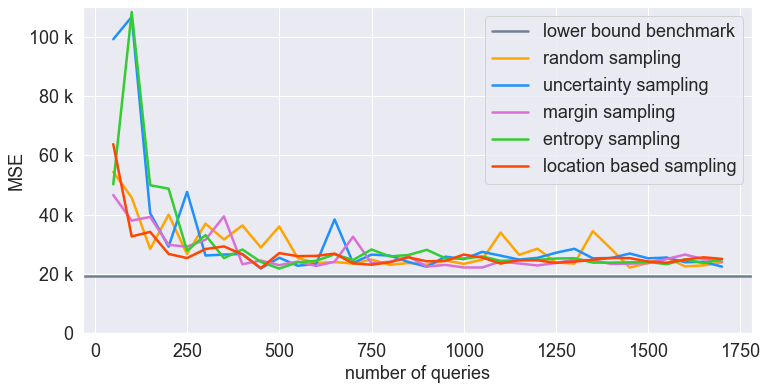

In [14]:
# after bootstrap
# mse_dict_uncertainty_all = {50: 65274.10617262323, 100: 47983.413478226925, 150: 26983.203641819764, 200: 23294.31099955719, 250: 25767.44701760128, 300: 31415.140141454478, 350: 31105.991843989013, 400: 27092.073001079134, 450: 35079.79240952116, 500: 24737.2838222193, 550: 23151.96876497875, 600: 24261.26749647967, 650: 24512.062144447933, 700: 24604.692696459675, 750: 24176.277237716175, 800: 26059.26547327766, 850: 27632.748908348494, 900: 23435.436915971364, 950: 23772.73363501368, 1000: 22879.49065328263, 1050: 22032.062414307245, 1100: 23282.969981022256, 1150: 24243.42911624546, 1200: 23321.90422994128, 1250: 21807.755052372228, 1300: 25105.341141332796, 1350: 26304.221968649636, 1400: 24385.826748441923, 1450: 23298.717850202564, 1500: 23529.185271881477, 1550: 23792.64497272381, 1600: 22563.45969709588, 1650: 23508.140939580797, 1700: 25171.42693264304}
# mse_dict_random_all = {50: 43938.65473272116, 100: 45414.48644163506, 150: 32936.1708191538, 200: 28020.95655935872, 250: 46733.35922744398, 300: 34855.51274405723, 350: 25121.05109737441, 400: 26326.092118955086, 450: 25623.495805314145, 500: 26046.956065929753, 550: 23262.249193148164, 600: 26053.763465327404, 650: 29358.360986277115, 700: 23846.1502608646, 750: 28413.213935541935, 800: 28401.46385156857, 850: 23584.242291479484, 900: 28901.89881011218, 950: 23808.375253824895, 1000: 22714.573657607438, 1050: 24120.740246977162, 1100: 26703.728214707702, 1150: 24717.33998396136, 1200: 42419.127575922765, 1250: 25372.907570312494, 1300: 34131.830719717196, 1350: 25395.34618173241, 1400: 26233.997076685435, 1450: 24542.40961228075, 1500: 23536.65718857488, 1550: 25567.64369904011, 1600: 26314.55865681308, 1650: 23815.499750545205, 1700: 24171.411069551297}

# mse_dict_margin_all = {50: 51284.7889639079, 100: 66016.85194045343, 150: 30273.315947502284, 200: 30510.82017951523, 250: 101819.90187829953, 300: 38640.28536421815, 350: 61023.50973416321, 400: 39791.17053809991, 450: 33765.272898954434, 500: 25399.624299885418, 550: 25295.027473948994, 600: 29622.44115548955, 650: 22079.748127691277, 700: 26585.907866276033, 750: 23744.630069383275, 800: 33232.0238208386, 850: 22102.53742151872, 900: 22752.360947639696, 950: 24208.144510679806, 1000: 21562.274649640396, 1050: 26998.73762918318, 1100: 24560.675992117074, 1150: 22452.813376793336, 1200: 23929.085556499747, 1250: 21515.396521110073, 1300: 21002.850865800327, 1350: 20719.38535556257, 1400: 22377.759285214455, 1450: 21627.643168845763, 1500: 22310.4018052671, 1550: 22741.272950609113, 1600: 21881.32329409153, 1650: 27603.12559227485, 1700: 24481.910818201824}
# mse_dict_entropy_all = {50: 28380.728995871905, 100: 25999.777289061687, 150: 22867.76505331373, 200: 28199.529204771632, 250: 25441.47017795502, 300: 25003.850975922735, 350: 23999.76663088189, 400: 23389.13185333071, 450: 28617.153615144096, 500: 21572.535891404164, 550: 23780.802876654794, 600: 27012.64679644414, 650: 24011.72121292667, 700: 38444.200770061805, 750: 22689.47333404826, 800: 25654.592084456395, 850: 28205.596121859, 900: 25440.040743286863, 950: 25117.27085514094, 1000: 23442.317186662574, 1050: 23036.608919064194, 1100: 23096.5961593425, 1150: 23124.530170379745, 1200: 24805.102946529525, 1250: 25953.39294655282, 1300: 23577.54266208186, 1350: 25200.517051388724, 1400: 24119.660713122023, 1450: 25046.87818086985, 1500: 23816.1011390917, 1550: 24551.050842369663, 1600: 21517.733642173673, 1650: 24585.92453574138, 1700: 24052.50585216122}

mse_dict_margin_all = {50: 46633.35359328566, 100: 38005.41705630582, 150: 39249.87546206821, 200: 29813.05147168828, 250: 29219.8147605367, 300: 31552.01148503668, 350: 39444.50767028116, 400: 23279.723602670467, 450: 24544.482199098198, 500: 22988.588913013355, 550: 24169.44946891, 600: 22725.189006493423, 650: 24152.24883915028, 700: 32568.761711374576, 750: 23617.64915632563, 800: 24123.805502526026, 850: 25892.84108814674, 900: 22502.881617429488, 950: 23077.370557246628, 1000: 22201.03501724068, 1050: 22198.74713721503, 1100: 24227.310540934417, 1150: 23541.622098884447, 1200: 22881.48416744651, 1250: 23719.503946443754, 1300: 24861.39726243947, 1350: 24569.38248002992, 1400: 23388.655878464662, 1450: 23506.674083450227, 1500: 23639.984702158483, 1550: 25034.426894635242, 1600: 26560.7392257153, 1650: 25014.00718311471, 1700: 24205.193511871945}

mse_dict_entropy_all = {50: 50246.38597293282, 100: 108369.65186053282, 150: 49938.523746834406, 200: 48780.43975068068, 250: 27894.539577084444, 300: 33126.16999655363, 350: 25349.32176210722, 400: 28272.339501405644, 450: 24079.287182564894, 500: 21832.940911211805, 550: 23944.04742003596, 600: 24446.211707847993, 650: 26667.946951450373, 700: 24713.371929612807, 750: 28266.449858698714, 800: 25933.75825109043, 850: 26409.115129914648, 900: 28153.122078499397, 950: 25313.690253845267, 1000: 25191.655530371834, 1050: 25923.881146495067, 1100: 24440.51523808439, 1150: 24627.62262974856, 1200: 24766.318320364877, 1250: 25214.62242028105, 1300: 25316.38336695712, 1350: 23837.202334005004, 1400: 23840.33948969573, 1450: 23952.24882113215, 1500: 24047.156885550783, 1550: 23313.19834166511, 1600: 24913.654105655096, 1650: 23663.71214437005, 1700: 25001.02493983885}

mse_dict_uncertainty_all = {50: 99168.55319229933, 100: 106737.7608221487, 150: 40507.57993314506, 200: 29226.95009948398, 250: 47702.33639518253, 300: 26235.96226212497, 350: 26546.65367102637, 400: 26761.424175882716, 450: 21862.06694008213, 500: 25487.671367540937, 550: 22775.621299090202, 600: 23450.86779503137, 650: 38416.32378666169, 700: 23723.01818050076, 750: 26549.980874794495, 800: 26189.739491579283, 850: 24057.308166884453, 900: 22444.547333268576, 950: 25852.951374009925, 1000: 24998.703021440484, 1050: 27472.51134567252, 1100: 26190.15715230383, 1150: 24862.332061392546, 1200: 25440.796553500517, 1250: 27167.93965413079, 1300: 28498.3913922542, 1350: 25300.191707868133, 1400: 25401.98880281988, 1450: 26903.46589321538, 1500: 25297.00423120307, 1550: 25537.50647774972, 1600: 23970.191023873802, 1650: 24100.79393282654, 1700: 22480.446288293097}

mse_dict_random_all = {50: 54412.70352942712, 100: 45775.9557070879, 150: 28430.72619135999, 200: 40013.996704858866, 250: 26771.789789525425, 300: 36969.46144346124, 350: 31638.96536644742, 400: 36373.32975500199, 450: 28937.316213204656, 500: 36033.264112267956, 550: 25393.960808753967, 600: 23709.749813778802, 650: 23997.498303388566, 700: 23529.46101654271, 750: 24867.421178324086, 800: 23071.597988110338, 850: 23709.99753168535, 900: 23145.155453912143, 950: 24569.237344793535, 1000: 23412.636832546235, 1050: 24829.631483260117, 1100: 33964.85751870691, 1150: 26467.27092209886, 1200: 28526.756863790637, 1250: 23862.601855296918, 1300: 23510.736584693415, 1350: 34450.63317094805, 1400: 28424.21738971304, 1450: 22175.689681727352, 1500: 23763.00203858809, 1550: 25522.653068127067, 1600: 22553.597944912548, 1650: 22903.460953944334, 1700: 23941.02632201611}


mse_dict_lb_all = {50: 63793.35322866152, 100: 32665.356391725833, 150: 34213.24419108607, 200: 26765.756906961014, 250: 25376.85146811727, 300: 28418.046579956677, 350: 29304.314415479155, 400: 26617.188472220285, 450: 21986.99545489457, 500: 27044.578759677042, 550: 26015.64067332863, 600: 26112.666300902518, 650: 26878.31881444877, 700: 23572.085488308778, 750: 23129.61983193779, 800: 23972.044759768425, 850: 25618.858473716307, 900: 24282.93427938715, 950: 24407.91556466366, 1000: 26548.71274406271, 1050: 25551.41504941434, 1100: 23520.8412533955, 1150: 24691.729223783375, 1200: 24615.35257332175, 1250: 23756.42507398524, 1300: 24189.57145174289, 1350: 24794.736088634283, 1400: 25414.917041573077, 1450: 25354.127418572298, 1500: 24223.09591946796, 1550: 23802.236780412073, 1600: 24847.60547115233, 1650: 25630.959525050504, 1700: 25096.959217328127}

n_queries = list(mse_dict_uncertainty_all.keys())
mses_random_all = list(mse_dict_random_all.values())
mses_uncertainty_all = list(mse_dict_uncertainty_all.values())
mses_margin_all = list(mse_dict_margin_all.values())
mses_entropy_all = list(mse_dict_entropy_all.values())
mses_lb_all = list(mse_dict_lb_all.values())[:len(n_queries)]


font_size = 18
line_width = 2.5
import matplotlib.ticker as ticker
sns.set()
fig, ax = plt.subplots(figsize=(12, 6))
#plt.figure(figsize=(12, 6))
y_bm = 19258.3560

plt.axhline(y=y_bm, color='slategray', linestyle='-', label="lower bound benchmark", linewidth=line_width)
plt.plot(n_queries, mses_random_all, label="random sampling", linewidth=line_width, color="orange")
plt.plot(n_queries, mses_uncertainty_all, label="uncertainty sampling", linewidth=line_width, color="dodgerblue")
plt.plot(n_queries, mses_margin_all, label="margin sampling", linewidth=line_width, color="orchid")
plt.plot(n_queries, mses_entropy_all, label="entropy sampling", linewidth=line_width, color="limegreen")
plt.plot(n_queries, mses_lb_all, label="location based sampling", linewidth=line_width, color="orangered")


plt.ylabel("MSE", fontsize=font_size)
plt.xlabel("number of queries", fontsize=font_size)
plt.legend(prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)

plt.ylim((0, 110000))
ax.yaxis.set_major_formatter(ticker.EngFormatter())

Text(0.5, 0, 'MSE')

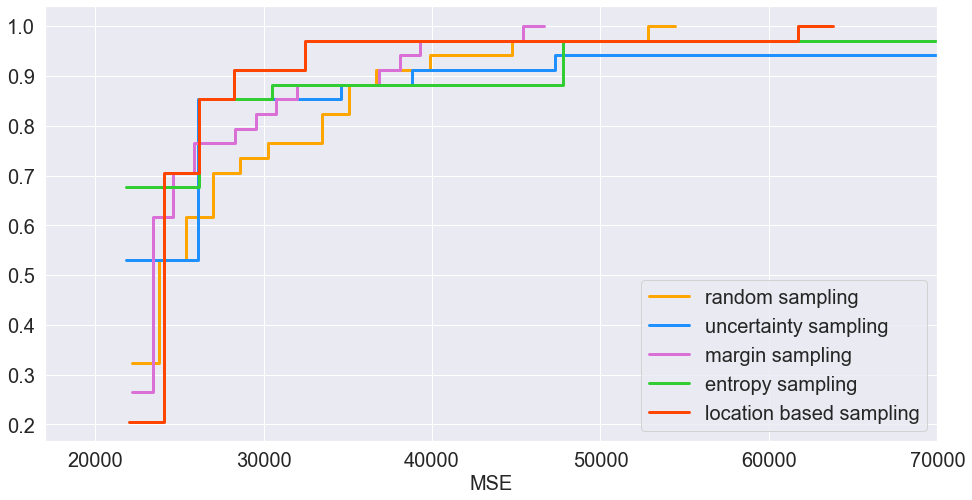

In [15]:
fig, ax = plt.subplots(figsize=(16, 8))
font_size = 20
line_width = 3
colors = {
    "uncertainty": "dodgerblue",
    "margin": "orchid",
    "entropy": "limegreen",
    "random": "orange",
    "location based": "orangered",
    "full": "slategray"
}
def plot_qs_cdf(qs_name, qs_var):
    counts, bins = np.histogram(qs_var, bins=20)
    cdf = np.cumsum(counts)/np.sum(counts)

    plt.plot(
        np.vstack((bins, np.roll(bins, -1))).T.flatten()[:-2],
        np.vstack((cdf, cdf)).T.flatten(), label=f"{qs_name} sampling",
        linewidth=line_width,
        color=colors[qs_name]
    )

plot_qs_cdf("random", mses_random_all)
plot_qs_cdf("uncertainty", mses_uncertainty_all)
plot_qs_cdf("margin", mses_margin_all)
plot_qs_cdf("entropy", mses_entropy_all)
plot_qs_cdf("location based", mses_lb_all)

plt.xlim(17000, 70000)
plt.legend(loc="lower right", prop={'size': font_size})
plt.xticks(fontsize=font_size)
plt.yticks(fontsize=font_size)
plt.xlabel("MSE", fontsize=font_size)

Text(0.5, 1.0, 'location based')

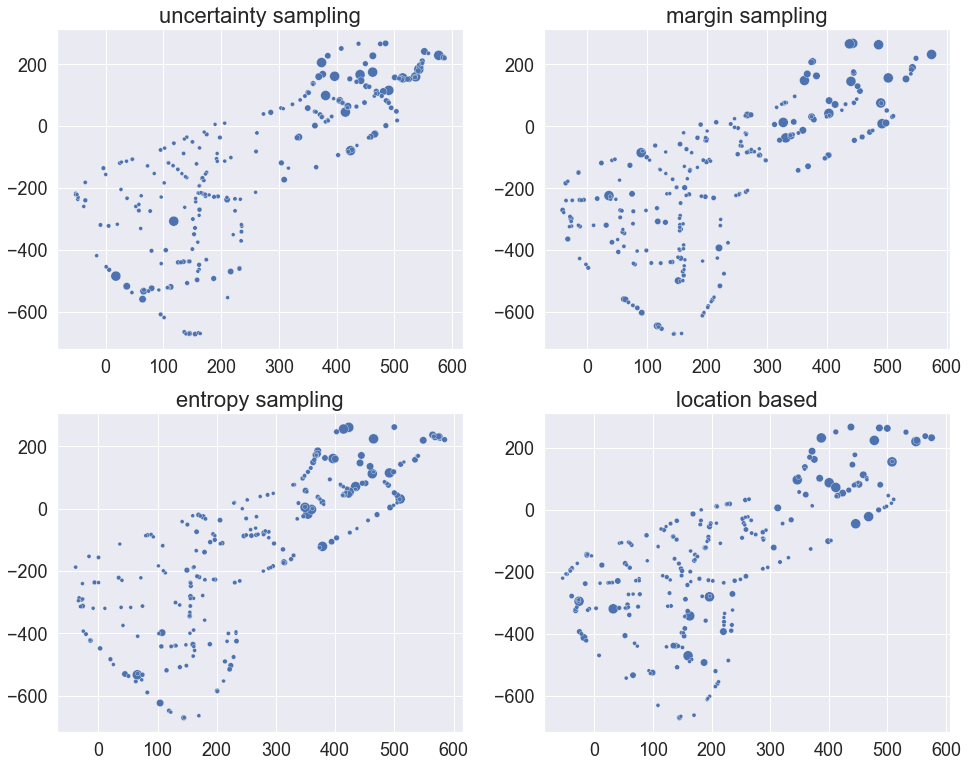

In [16]:
# Looking at the chosen samples by the 4 uncertainty sampling methods
plt.subplots(2, 2, figsize=(16, 20))
font_size = 18
fs_title = 22

def plot_qs_chosen(qs_name, idx):
    df_chosen = pd.read_csv(f"chosen/cnn_ae_al2_{qs_name}_all_chosen_250iter.csv", index_col=0)
    df_chosen["iter"] = df_chosen["iter"] + 1
    batch = 15
    df_chosen["size"] = df_chosen["iter"].apply(lambda val: 5 / (((val - (val % batch)) / batch) + 1))
    sns.set()
    plt.subplot(3, 2, idx)
    ax = sns.scatterplot(x="x", y="y", data=df_chosen, size="size", sizes=(15, 100))
    plt.title(f"{qs_name} sampling", fontsize=fs_title)
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    plt.xlabel("MSE", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    ax.get_legend().remove()

#plot_qs_chosen("random", 1)
plot_qs_chosen("uncertainty", 1)
plot_qs_chosen("margin", 2)
plot_qs_chosen("entropy", 3)
plot_qs_chosen("lb2", 4)
plt.title("location based", fontsize=fs_title)

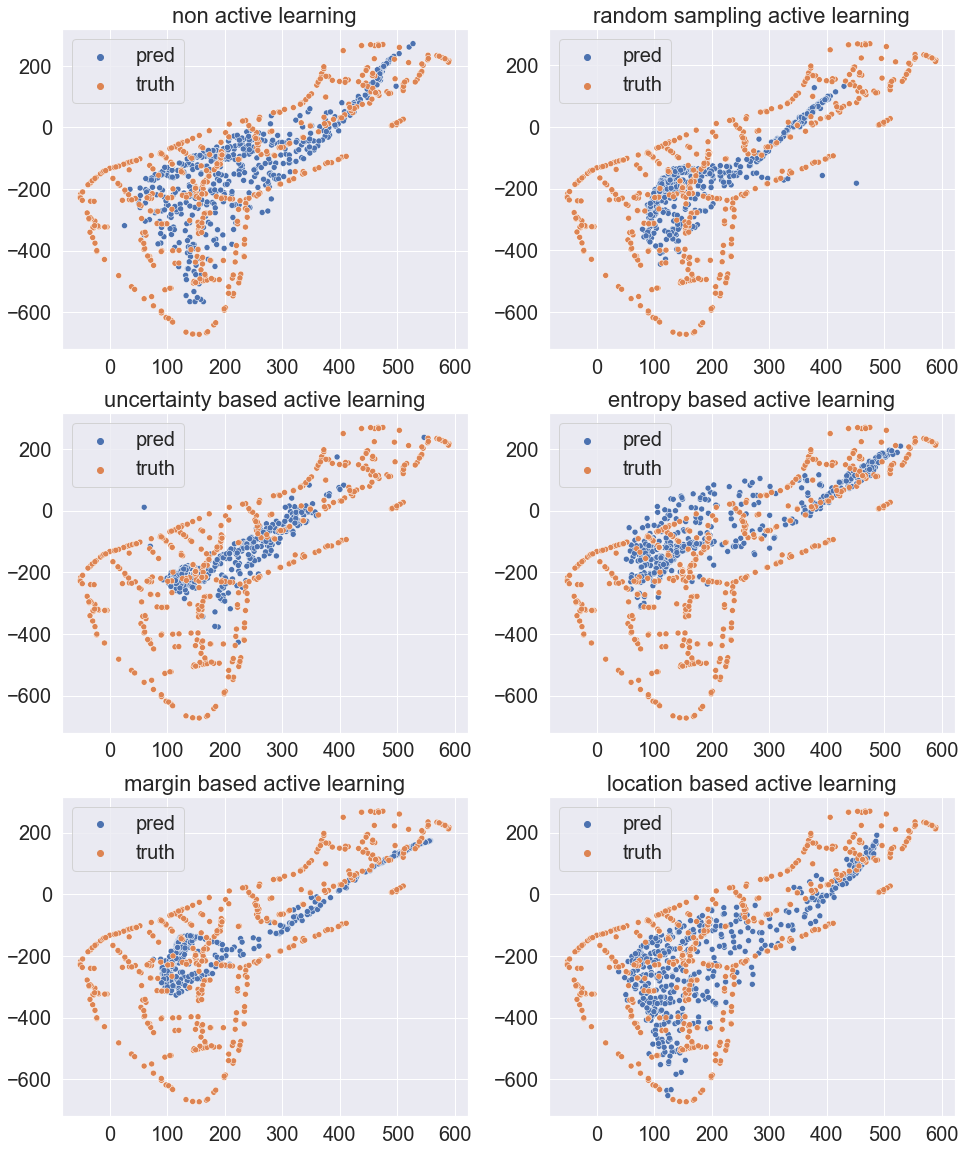

In [13]:
font_size = 20
fs_title = 22
def _plot_qs_comp(y_test, filename, title):
    file = f"{filename}.csv"
    preds = pd.read_csv(f"preds/{file}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test, columns=["x", "y", "z"])
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], ignore_index=True)
    concat = concat[concat["x"]<600]
    ax = sns.scatterplot(x="x", y="y", data=concat, hue="type")
#     plt.ylabel("y", fontsize=font_size)
#     plt.xlabel("x", fontsize=font_size)
    ax.xaxis.label.set_visible(False)
    ax.yaxis.label.set_visible(False)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    ax.set_title(title, fontsize=fs_title)

def compare_predictions(y_test, x_test=None, model=None):
    plt.subplots(3, 2, figsize=(16, 20))
    plt.subplot(3, 2, 1)
    _plot_qs_comp(y_test, "cnn_ae_full_all_preds", "non active learning")
    
    plt.subplot(3, 2, 2)
    _plot_qs_comp(y_test, "cnn_ae_al2_random_650", "random sampling active learning")

    plt.subplot(3, 2, 3)
    _plot_qs_comp(y_test, "cnn_ae_al2_uncertainty_650", "uncertainty based active learning")
    
    plt.subplot(3, 2, 4)
    _plot_qs_comp(y_test, "cnn_ae_al2_entropy_650", "entropy based active learning")
    
    plt.subplot(3, 2, 5)
    _plot_qs_comp(y_test, "cnn_ae_al2_margin_650", "margin based active learning")
    
    plt.subplot(3, 2, 6)
    _plot_qs_comp(y_test, "cnn_ae_al3_lb2_all_preds", "location based active learning")
    
    
compare_predictions(y_test_ae)

(-100.0, 700.0)

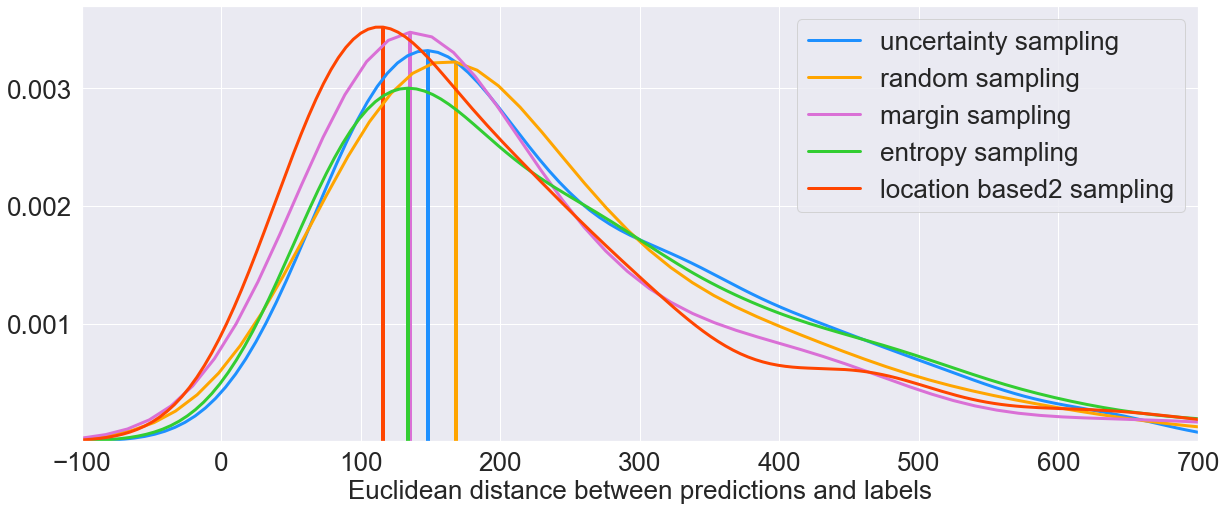

In [12]:
#fig, axes = plt.subplots(3, 1, figsize=(16, 11))
colors = {
    "uncertainty": "dodgerblue",
    "margin": "orchid",
    "entropy": "limegreen",
    "random": "orange",
    "location based2": "orangered",
    "full": "slategray"
}
line_width = 3
v_line_width = 4
font_size = 26
sns.set()

def plot_diff_kde(filename, label, line_idx, axis="x"):
    preds = pd.read_csv(f"preds/{filename}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test_ae_cnn, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], axis=1, ignore_index=True)
    concat.columns = ["x_p", "y_p", "z_p", "t1", "x_t", "y_t", "z_t", "t2"]
    concat[f"{axis}_diff"] = abs(concat[f"{axis}_p"] - concat[f"{axis}_t"])
    p = sns.kdeplot(concat[f"{axis}_diff"], label=label, color=colors[label], linewidth=line_width)
    x, y = p.get_lines()[line_idx].get_data()
    y_argmax = np.argmax(y)
    x_curt = (x[y_argmax] + x[y_argmax + 1]) / 2
    
    plt.vlines(x_curt, 0, y[y_argmax], color=colors[label], linewidth=v_line_width)
    if axis == "x":
        plt.xlim(-60, 400)
        plt.xticks(np.arange(-50, 450, 50))
        plt.yticks([0, 0.002, 0.004, 0.006])
    elif axis == "y":
        plt.xlim(-100, 600)
        plt.xticks(np.arange(-100, 650, 50))
        plt.yticks([0, 0.001, 0.002, 0.003, 0.004])
    elif axis == "z":
        plt.xticks(np.arange(-10, 70, 10))
        plt.xlim(-10, 60)
    plt.legend()
    plt.ylabel("")
    plt.xlabel(f"diff in {axis} axis", fontsize=font_size)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks(fontsize=font_size)
    
def euclidean(x_diff, y_diff, z_diff):
    return math.sqrt(x_diff**2 + y_diff**2 + z_diff**2)
    
def plot_diff_kde_xyz(filename, label, line_idx):
    preds = pd.read_csv(f"preds/{filename}")
    preds = preds[["x", "y", "z"]]
    preds["type"] = "pred"
    truth = pd.DataFrame(y_test_ae_cnn, columns=["x", "y", "z"])
    truth = truth[["x", "y", "z"]]
    truth["type"] = "truth"
    concat = pd.concat([preds, truth], axis=1, ignore_index=True)
    concat.columns = ["x_p", "y_p", "z_p", "t1", "x_t", "y_t", "z_t", "t2"]
    concat["x_diff"] = abs(concat["x_p"] - concat["x_t"])
    concat["y_diff"] = abs(concat["y_p"] - concat["y_t"])
    concat["z_diff"] = abs(concat["z_p"] - concat["z_t"])
    concat["eucl"] = concat.apply(lambda row: euclidean(row["x_diff"], row["y_diff"], row["z_diff"]), axis=1)
    
    p = sns.kdeplot(concat[f"eucl"], label=label + " sampling", color=colors[label], linewidth=line_width)
    x, y = p.get_lines()[line_idx].get_data()
    y_argmax = np.argmax(y)
    x_curt = x[y_argmax]
    plt.vlines(x_curt, 0, max(y), color=colors[label], linewidth=v_line_width)
    plt.legend()
    plt.ylabel("")
    plt.xlabel(f"Euclidean distance between predictions and labels", fontsize=font_size)
    plt.legend(prop={'size': font_size})
    plt.xticks(fontsize=font_size)
    plt.yticks([0.001, 0.002, 0.003], fontsize=font_size)
    
fig, axes = plt.subplots(figsize=(20, 8))
plot_diff_kde_xyz("cnn_ae_al2_uncertainty_650.csv", "uncertainty", 0)
plot_diff_kde_xyz("cnn_ae_al2_random_650.csv", "random", 1)
plot_diff_kde_xyz("cnn_ae_al2_margin_500.csv", "margin", 2)
plot_diff_kde_xyz("cnn_ae_al2_entropy_650.csv", "entropy", 3)
plot_diff_kde_xyz("cnn_ae_al3_lb2_all_preds.csv", "location based2", 4)
plt.xlim(-100, 700)

# plt.subplot(3, 1, 1)
# plot_diff_kde("cnn_ae_al2_uncertainty_all_preds.csv", "uncertainty", 0, "x")
# plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "x")
# plot_diff_kde("cnn_ae_al2_entropy_all_preds.csv", "entropy", 2, "x")
# plot_diff_kde("cnn_ae_al2_margin_all_preds.csv", "margin", 3, "x")
# plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "x")

# plt.subplot(3, 1, 2)
# plot_diff_kde("cnn_ae_al2_uncertainty_all_preds.csv", "uncertainty", 0, "y")
# plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "y")
# plot_diff_kde("cnn_ae_al2_entropy_all_preds.csv", "entropy", 2, "y")
# plot_diff_kde("cnn_ae_al2_margin_all_preds.csv", "margin", 3, "y")
# plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "y")

# plt.subplot(3, 1, 3)
# plot_diff_kde("cnn_ae_al2_uncertainty_all_preds.csv", "uncertainty", 0, "z")
# plot_diff_kde("cnn_ae_al1_random_all_preds.csv", "random", 1, "z")
# plot_diff_kde("cnn_ae_al2_entropy_all_preds.csv", "entropy", 2, "z")
# plot_diff_kde("cnn_ae_al2_margin_all_preds.csv", "margin", 3, "z")
# plot_diff_kde("cnn_ae_al1_lb_all_preds.csv", "location based", 4, "z")

#fig.tight_layout()